In [329]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm

import torch 
from torch import nn, Tensor
from torch.utils.data import TensorDataset, DataLoader
import torch.distributions as D

import seaborn as sns

from sklearn.datasets import make_moons

SEED = 42

PAPER = False

# Test lib

In [175]:
class Flow(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        return self.net(torch.cat((t, x_t), -1))
    
    def step(self, x_t: Tensor, t_start: Tensor, t_end: Tensor) -> Tensor:
        t_start = t_start.view(1, 1).expand(x_t.shape[0], 1)
        
        return x_t + (t_end - t_start) * self(t=t_start + (t_end - t_start) / 2, x_t= x_t + self(x_t=x_t, t=t_start) * (t_end - t_start) / 2)

In [176]:
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_1 = Tensor(make_moons(256, noise=0.15)[0])
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

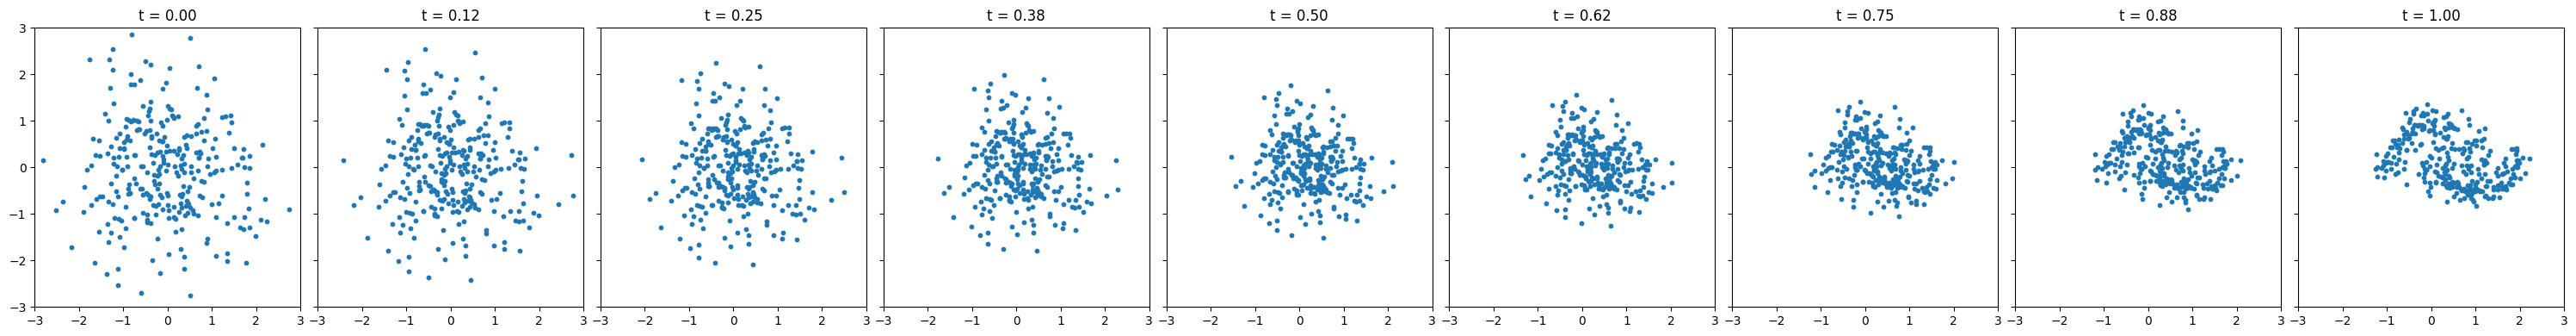

In [177]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-3.0, 3.0)
axes[0].set_ylim(-3.0, 3.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

Citation from On the Relation between Rectified Flows and Optimal Transport

**Theorem 3 (Gaussian Case)**  
Assume that $(X_0, X_1) \sim \mathcal{N}(0, \Sigma)$ with 
$\Sigma = 
\begin{pmatrix}
\Sigma_{0} & \Sigma_{10}\\
\Sigma_{01} & \Sigma_{1}
\end{pmatrix}$,
for positive definite $\Sigma_{0}$ and $\Sigma_{1}$. Then, the following holds true.

The minimizer $v_t = \arg\min_{w_t} \mathcal{L}(w_t \, | \, X_0, X_1)$ of the loss function (1) is given by
$$
v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
x
$$


where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.




Then we can write
$$
J_t = \nabla_x v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
$$,

where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.

# Normal to normal

Case 1:  
$X_0 \sim \mathcal{N}(0, \Sigma_{0})$ with
$$\Sigma_{0} = 
\begin{pmatrix}
9 & 0\\
0 & 9
\end{pmatrix}$$

Warning ! hereafter X_1 and X_0 are permuted

In [178]:
torch.manual_seed(SEED)
flow = Flow()

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_1 = torch.randn(256, 2) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

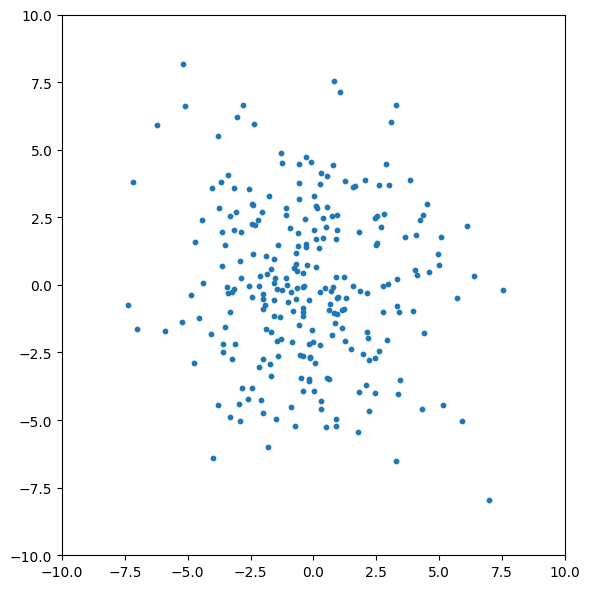

In [179]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharex=True, sharey=True)

ax.scatter(x_1.detach()[:, 0], x_1.detach()[:, 1], s=10)
ax.set_xlim(-10.0, 10.0)
ax.set_ylim(-10.0, 10.0)

plt.tight_layout()
plt.show()

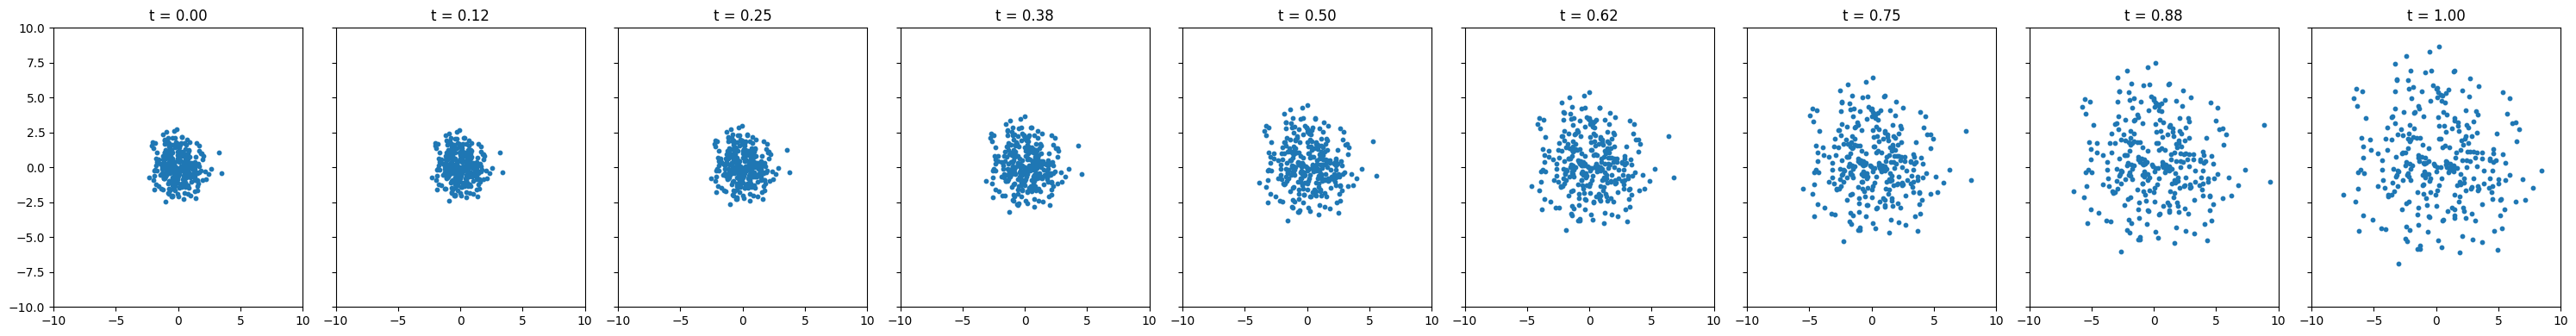

In [180]:
x = torch.randn(300, 2)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

Citation from On the Relation between Rectified Flows and Optimal Transport

**Theorem 3 (Gaussian Case)**  
Assume that $(X_0, X_1) \sim \mathcal{N}(0, \Sigma)$ with 
$\Sigma = 
\begin{pmatrix}
\Sigma_{0} & \Sigma_{10}\\
\Sigma_{01} & \Sigma_{1}
\end{pmatrix}$,
for positive definite $\Sigma_{0}$ and $\Sigma_{1}$. Then, the following holds true.

The minimizer $v_t = \arg\min_{w_t} \mathcal{L}(w_t \, | \, X_0, X_1)$ of the loss function (1) is given by
$$
v_t(x) = \frac{1}{1 - t}
\Big (
((1 - t)\Sigma_{01} + t\Sigma_1)\Sigma_t^{-1}
- \text{Id}
\Big )
x
$$


where
$\Sigma_{t} = \text{Cov}(X_t) = (1 - t)^2 \Sigma_{0} + (1 - t)t(\Sigma_{01} + \Sigma_{10}) + t^2 \Sigma_{1}$.




$p_0 \sim \mathcal{N}$ and $p_1 \sim p_\text{data}$

ligne de v

In [181]:
def theory_basis_normal_coupling(coupling, t):
    d = coupling.shape[0] // 2
    Sigma_0 = coupling[:d, :d]
    Sigma_1 = coupling[d:, d:]
    Sigma_10 = coupling[:d, d:]
    Sigma_01 = coupling[d:, :d]

    Sigma_t = (1 - t) ** 2 * Sigma_0 + (1 - t) * t * (Sigma_01 + Sigma_10) + t ** 2 * Sigma_1

    Jac_v_t = (1 / (1 - t)) * (((1 - t) * Sigma_01 + t * Sigma_1) @ torch.linalg.inv(Sigma_t) - torch.eye(d))
    U, S, Vh = torch.linalg.svd(Jac_v_t)
    return Vh

coupling = Tensor([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 9, 0], [0, 0, 0, 9]])
t = 0.5
theory_basis_normal_coupling(coupling, t)

tensor([[1., 0.],
        [0., 1.]])

In [182]:
import torch

def compute_jacobian(flow, t, x):
    x = x.detach().clone().requires_grad_(True)

    def flow_fn(x_):
        t_tensor = torch.tensor([t], dtype=x_.dtype, device=x_.device)
        return flow(t=t_tensor, x_t=x_)

    # jac: shape (out_dim, in_dim)
    jac = torch.autograd.functional.jacobian(flow_fn, x, create_graph=False)

    U, S, Vh = torch.linalg.svd(jac)
    return Vh, S, jac

Vh, S, jac = compute_jacobian(flow, t=0.5, x=torch.randn(2))
Vh


tensor([[-0.9632,  0.2689],
        [ 0.2689,  0.9632]])

# high dim

In [183]:
torch.manual_seed(SEED)
flow = Flow(dim=100)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in tqdm(range(10000)):
    x_1 = torch.randn(2560, 100) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

100%|██████████| 10000/10000 [00:59<00:00, 167.63it/s]


In [184]:
import torch
torch.manual_seed(SEED)

def compute_jacobian(flow, t, x):
    x = x.detach().clone().requires_grad_(True)

    def flow_fn(x_):
        t_tensor = torch.tensor([t], dtype=x_.dtype, device=x_.device)
        return flow(t=t_tensor, x_t=x_)

    # jac: shape (out_dim, in_dim)
    jac = torch.autograd.functional.jacobian(flow_fn, x, create_graph=False)

    U, S, Vh = torch.linalg.svd(jac)
    return Vh, S, jac

Vh, S, jac = compute_jacobian(flow, t=0.5, x=torch.randn(100))
Vh[:, 0]

tensor([-0.0140,  0.0812, -0.0672,  0.0718, -0.0468,  0.1943, -0.0216,  0.1040,
        -0.0341,  0.1653, -0.0317,  0.0044,  0.0603, -0.0514,  0.1692, -0.1809,
         0.1348,  0.0704, -0.0494, -0.0306,  0.0370,  0.0717, -0.0667,  0.0370,
         0.0062,  0.1799, -0.0480, -0.0808,  0.0515,  0.0724,  0.0207, -0.1098,
        -0.0718,  0.1423, -0.0092, -0.0009, -0.0090, -0.0750,  0.1709, -0.2140,
        -0.0854, -0.0082,  0.0733,  0.2047, -0.1068, -0.1496,  0.1154,  0.0054,
        -0.1040,  0.1201, -0.0399, -0.0492,  0.2269, -0.0819,  0.1106, -0.0872,
         0.2588, -0.0168,  0.0024,  0.1026, -0.0733,  0.0084, -0.0443,  0.1421,
        -0.0602,  0.0324,  0.0000,  0.0000,  0.0000,  0.2624,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0667,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.1368,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -0.1606,  0.0000,
         0.0000, -0.4378,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

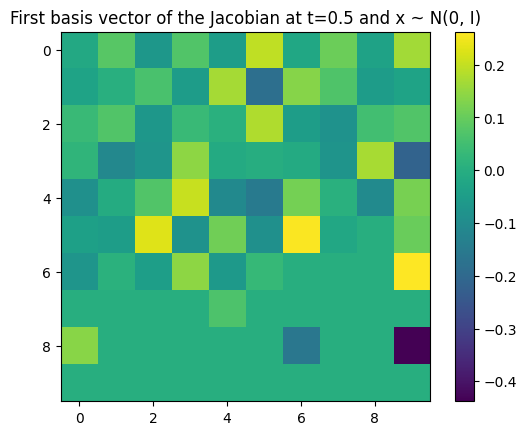

In [185]:
torch.manual_seed(SEED)
# this is the first basis vector of the Jacobian of the flow at t=0.5 and x ~ N(0, I) so the one with the largest singular value, i.e. the direction of maximal expansion of the flow at this point
Vh[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('First basis vector of the Jacobian at t=0.5 and x ~ N(0, I)')
plt.show()

In [186]:
# same coupling as before but with dim=100
coupling = torch.cat((torch.cat((torch.eye(100), torch.eye(100)), dim=1), torch.cat((torch.eye(100), 9 * torch.eye(100)), dim=1)), dim=0) 
t = 0.5
Vh_2 = theory_basis_normal_coupling(coupling, t)
Vh_2[:, 0]

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

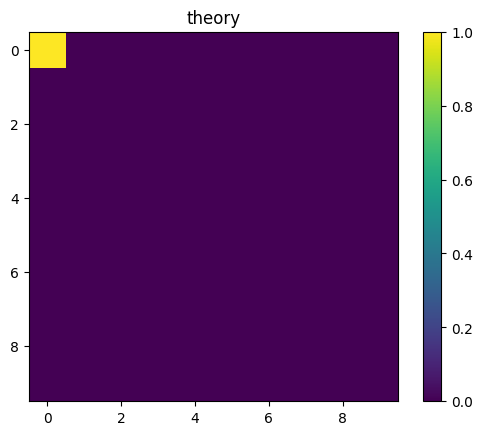

In [187]:
Vh_2[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh_2[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('theory')
plt.show()

100%|██████████| 10/10 [00:00<00:00, 599.78it/s]


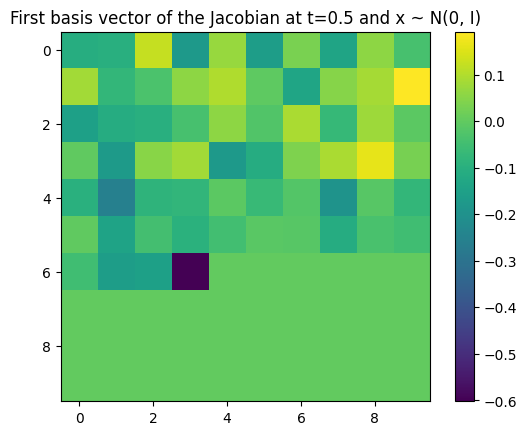

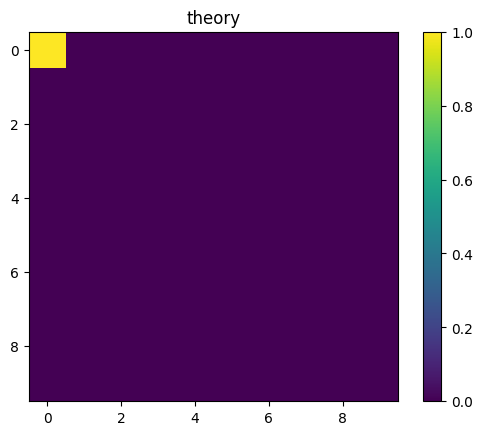

In [188]:
torch.manual_seed(SEED)
flow = Flow(dim=100)
n_sample = 256
n_epochs = 10

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

for _ in tqdm(range(n_epochs)):
    x_1 = torch.randn(n_sample, 100) * 3.0 # data
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), 1)
    
    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0
    
    optimizer.zero_grad()
    loss_fn(flow(t=t, x_t=x_t), dx_t).backward()
    optimizer.step()

Vh, S, jac = compute_jacobian(flow, t=0.5, x=torch.randn(100))

# now we print this vector as an image with color
plt.imshow(Vh[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('First basis vector of the Jacobian at t=0.5 and x ~ N(0, I)')

plt.show()
coupling = torch.cat((torch.cat((torch.eye(100), torch.eye(100)), dim=1), torch.cat((torch.eye(100), 9 * torch.eye(100)), dim=1)), dim=0) 
t = 0.5
Vh_2 = theory_basis_normal_coupling(coupling, t)
Vh_2[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh_2[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('theory')
plt.show()


In [189]:
S

tensor([2.2739e+00, 2.0288e+00, 1.8959e+00, 1.8501e+00, 1.7857e+00, 1.6266e+00,
        1.5637e+00, 1.4811e+00, 1.4066e+00, 1.2264e+00, 1.1172e+00, 9.3667e-01,
        8.9014e-01, 8.0836e-01, 7.5384e-01, 5.9714e-01, 5.1989e-01, 4.4650e-01,
        4.0346e-01, 3.4814e-01, 2.9690e-01, 2.9541e-01, 2.3170e-01, 2.1160e-01,
        1.6471e-01, 1.4536e-01, 1.3562e-01, 1.2139e-01, 9.6187e-02, 9.1875e-02,
        7.9342e-02, 7.1914e-02, 7.0010e-02, 5.2636e-02, 4.1311e-02, 3.9244e-02,
        3.2244e-02, 2.4217e-02, 2.1080e-02, 1.8497e-02, 1.5296e-02, 1.4849e-02,
        1.2790e-02, 1.0094e-02, 9.5473e-03, 8.5950e-03, 8.0608e-03, 5.1454e-03,
        5.0428e-03, 4.1876e-03, 3.4902e-03, 3.2072e-03, 2.8720e-03, 2.4000e-03,
        1.6278e-03, 1.3390e-03, 9.7325e-04, 6.3572e-04, 4.4714e-04, 3.8465e-04,
        1.4480e-04, 8.1501e-05, 5.2427e-05, 2.8606e-07, 1.4726e-07, 9.9588e-08,
        9.9588e-08, 9.9588e-08, 9.9588e-08, 9.9588e-08, 9.9588e-08, 9.9588e-08,
        9.9588e-08, 9.9588e-08, 9.9588e-

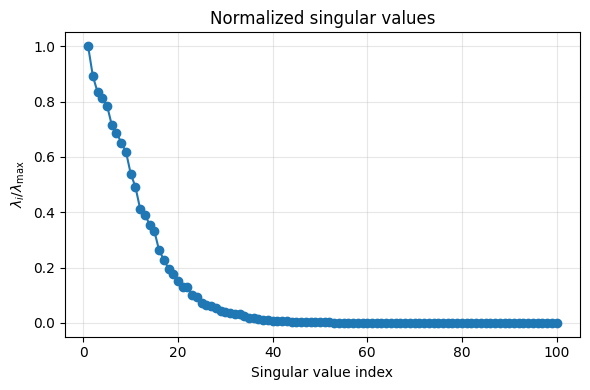

In [193]:
# plot the singular values normalized by the largest one
# Plot singular values normalized by the largest one
# (works if S is a torch tensor returned by torch.linalg.svd)
S = S.detach().cpu()
S_norm = S / S.max().clamp_min(1e-12)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(S_norm) + 1), S_norm.numpy(), marker="o")
plt.xlabel("Singular value index")
plt.ylabel(r"$\lambda_i / \lambda_{\max}$")
plt.title("Normalized singular values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

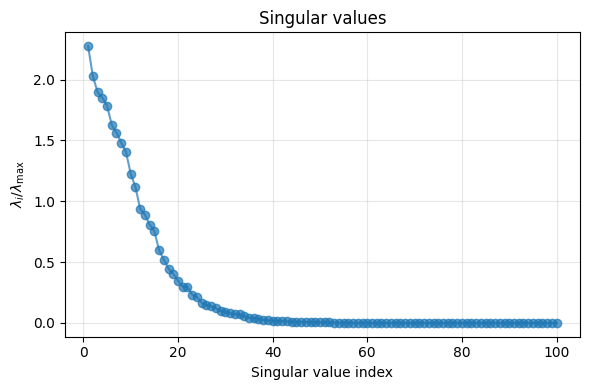

In [199]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(S_norm) + 1), S.numpy(), marker="o", alpha=0.7)
plt.xlabel("Singular value index")
plt.ylabel(r"$\lambda_i / \lambda_{\max}$")
plt.title("Singular values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Sampling

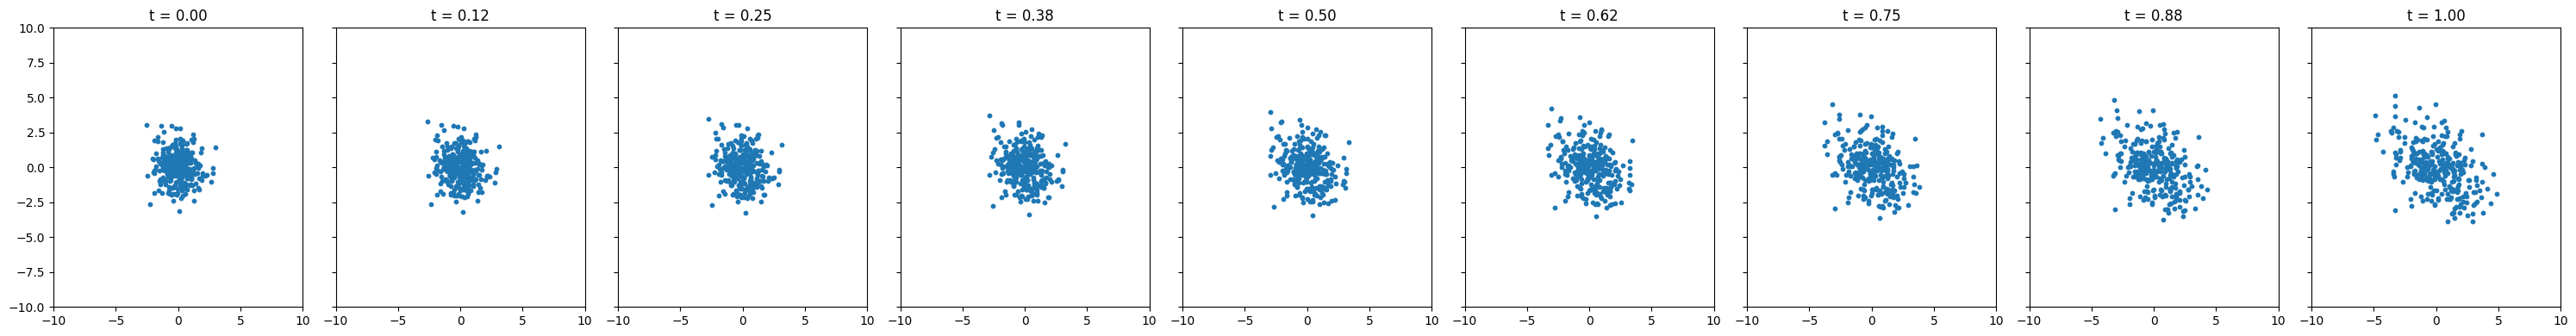

In [202]:
x = torch.randn(300, 100)
n_steps = 8
fig, axes = plt.subplots(1, n_steps + 1, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

plt.tight_layout()
plt.show()

# Fixed dataset

## Data

In [315]:
torch.manual_seed(SEED)
# 1) Dataset FIXE : X_0 = data
N = 100_000
batch_size = 256

#x0_all = torch.tensor(make_moons(N, noise=0.1, random_state=SEED)[0], dtype=torch.float32)  # data = X_0
x0_all = torch.randn(N, 100) * 3.0 # data

dataset = TensorDataset(x0_all)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

## Training

In [316]:
torch.manual_seed(SEED)
flow = Flow(dim=100)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

# 2) Train : X_1 = prior (normal) resamplée à chaque batch
num_epochs = 300
for epoch in range(num_epochs):
    for (batch_x,) in loader:
        x1 = batch_x
        x0 = torch.randn_like(x1)         
        t = torch.rand(len(x1), 1, device=x1.device)

        # Chemin: x_t = (1-t) x0 + t x1
        x_t = (1 - t) * x0 + t * x1
        # Pour ce chemin linéaire, la vitesse cible est constante
        dx_t = x1 - x0

        optimizer.zero_grad()
        loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
        loss.backward()
        optimizer.step()


## Sampling

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


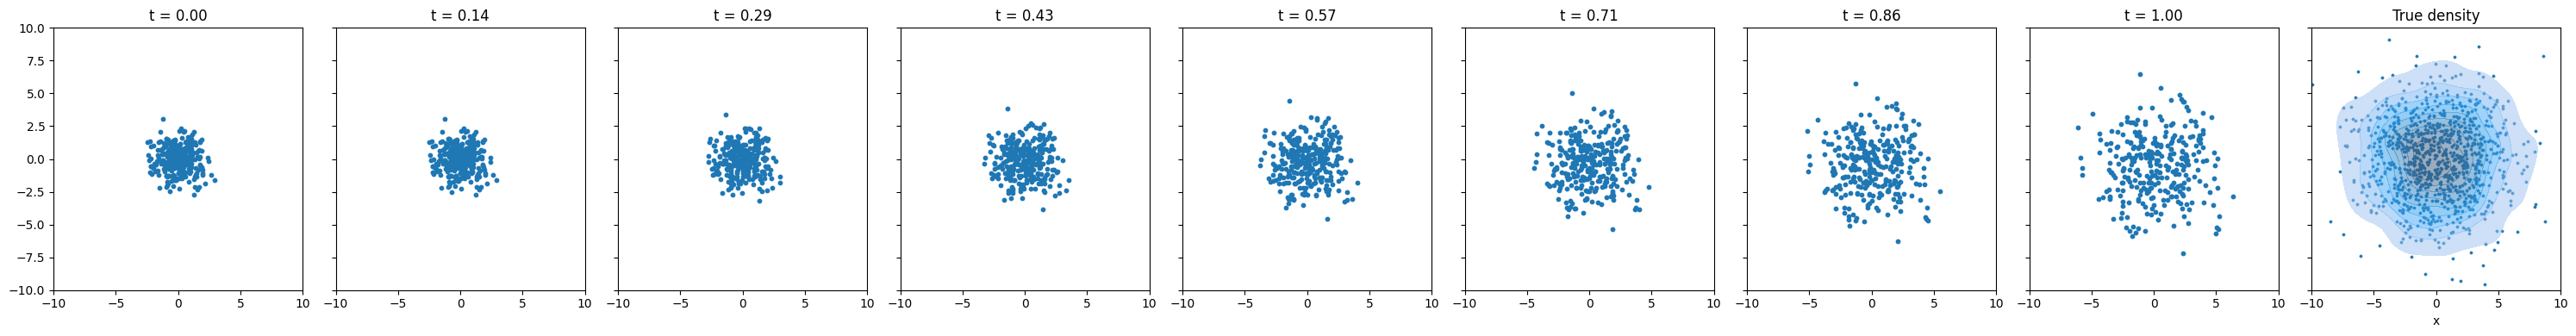

In [317]:
torch.manual_seed(SEED)
KDE_PLOT = True

x = torch.randn(300, 100)
n_steps = 7
fig, axes = plt.subplots(1, n_steps + 2, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')

# True density
LIMIT = 1000

df = pd.DataFrame({"x": x0_all.detach()[:LIMIT, 0], "y": x0_all.detach()[:LIMIT, 1]})

# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:blue", ax=axes[-1]
)

if KDE_PLOT:
    # KDE contour lines (few levels)
    sns.kdeplot(
        data=df, x="x", y="y",
        levels=10,          # few contour lines
        thresh=0.05,
        color="tab:blue",
        linewidths=1.2,
        fill=True, alpha=0.5,
        bw_adjust=1,     # tune smoothness
        ax=axes[-1]
    )
axes[-1].set_title(f'True density')


plt.tight_layout()
plt.show()

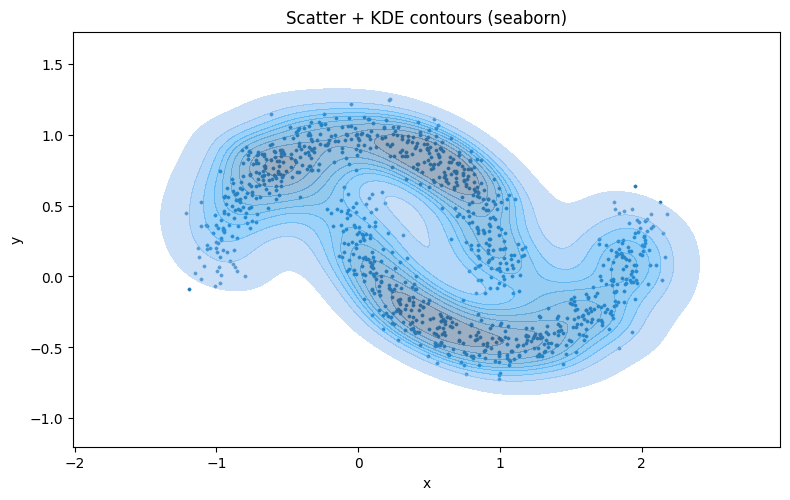

In [383]:
import seaborn as sns
import pandas as pd

# x_1 is assumed shape (N, 2), torch tensor or numpy array
pts = x_1.detach().cpu().numpy() if torch.is_tensor(x_1) else np.asarray(x_1)
df = pd.DataFrame({"x": pts[:, 0], "y": pts[:, 1]})

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:blue", ax=ax
)

# KDE contour lines (few levels)
sns.kdeplot(
    data=df, x="x", y="y",
    levels=10,          # few contour lines
    thresh=0.05,
    color="tab:blue",
    fill=True, alpha=0.5,
    bw_adjust=1,     # tune smoothness
    ax=ax
)

ax.set_title("Scatter + KDE contours (seaborn)")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


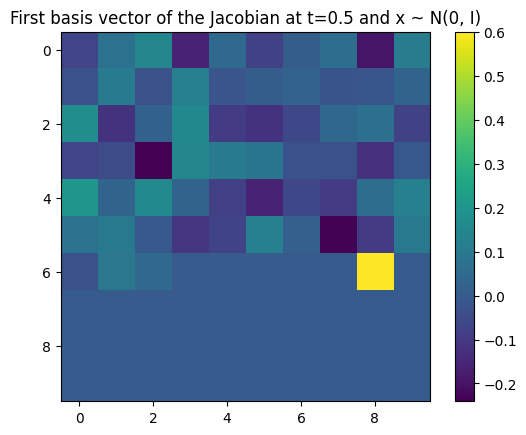

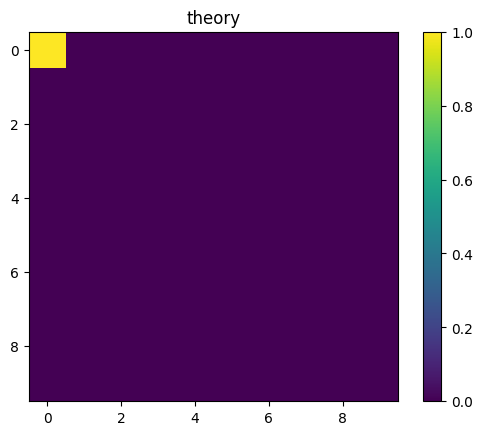

In [321]:
torch.manual_seed(SEED)
Vh, S, jac = compute_jacobian(flow, t=0.1, x=torch.randn(100))

# now we print this vector as an image with color
plt.imshow(Vh[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('First basis vector of the Jacobian at t=0.5 and x ~ N(0, I)')

plt.show()

coupling = torch.cat((torch.cat((torch.eye(100), torch.eye(100)), dim=1), torch.cat((torch.eye(100), 9 * torch.eye(100)), dim=1)), dim=0) 
t = 0.5
Vh_2 = theory_basis_normal_coupling(coupling, t)
Vh_2[:, 0]
# now we print this vector as an image with color
plt.imshow(Vh_2[:, 0].view(10, 10).detach().numpy(), cmap='viridis')
plt.colorbar()
if PAPER:
    plt.savefig('basis_vector.png', dpi=300)
else:
    plt.title('theory')
plt.show()

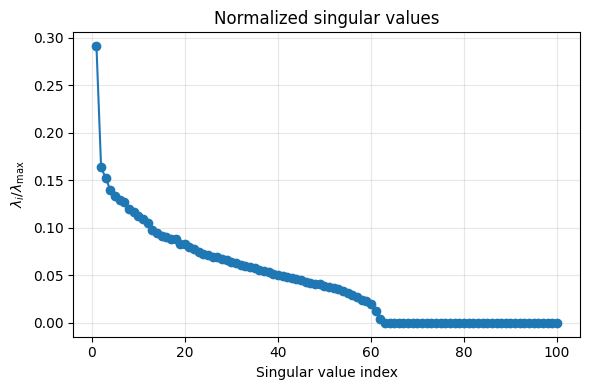

In [322]:
# plot the singular values normalized by the largest one
# Plot singular values normalized by the largest one
# (works if S is a torch tensor returned by torch.linalg.svd)
S = S.detach().cpu()
S_norm = S

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(S_norm) + 1), S_norm.numpy(), marker="o")
plt.xlabel("Singular value index")
plt.ylabel(r"$\lambda_i / \lambda_{\max}$")
plt.title("Normalized singular values")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gaussian mixture

## Data

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


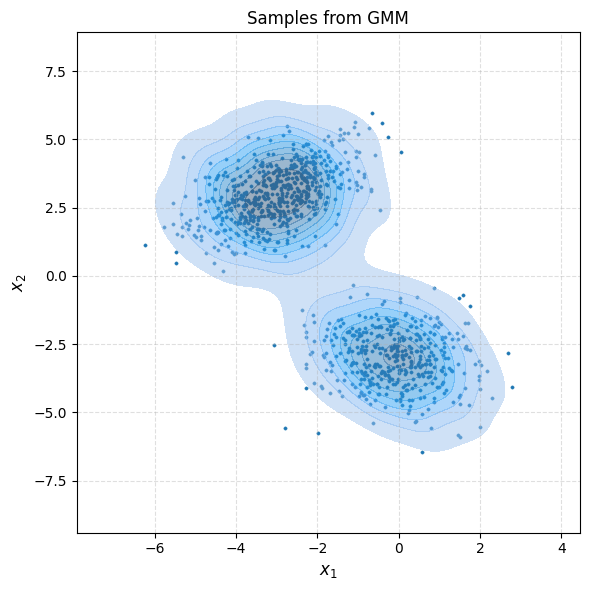

In [385]:
torch.manual_seed(SEED)
# 1) Dataset FIXE : X_0 = data
N = 100_000
batch_size = 256
N_components = 2
dim = 2

#x0_all = torch.tensor(make_moons(N, noise=0.1, random_state=SEED)[0], dtype=torch.float32)  # data = X_0
# gaussian data
x0_all = torch.randn(N, dim) * 3.0 # data

# Gaussian mixture
means = torch.tensor(
        [[-3, 3], [0, -3]],
        dtype=torch.float32,
    )
n_mix = means.shape[0]
covs = torch.tensor([
        [[1.0, 0.5], [0.5, 1.0]],
        [[1.0, 0], [0, 1.0]],
        ], dtype=torch.float32,
    )
weights = torch.rand(n_mix)
weights = weights / weights.sum()
gmm = D.MixtureSameFamily(
        mixture_distribution=D.Categorical(weights),
        component_distribution=D.MultivariateNormal(means, covs),
)

x0_all = gmm.sample((N,))

dataset = TensorDataset(x0_all)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

####### Plot
fig, ax = plt.subplots(figsize=(6, 6))
df = pd.DataFrame({"x": x0_all[:1000, 0], "y": x0_all[:1000, 1]})
# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:blue", ax=ax
)

# KDE contour lines (few levels)
sns.kdeplot(
    data=df, x="x", y="y",
    levels=10,          # few contour lines
    thresh=0.05,
    color="tab:blue",
    linewidths=1.2,
    fill=True, alpha=0.5,
    bw_adjust=1,     # tune smoothness
    ax=ax
)

ax.set_title("Samples from GMM")
#ax.set_aspect("equal", adjustable="box")
plt.xlabel("$x_1$", fontsize=12)
plt.ylabel("$x_2$", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Training

In [386]:
torch.manual_seed(SEED)
flow = Flow(dim=dim)

optimizer = torch.optim.Adam(flow.parameters(), 1e-2)
loss_fn = nn.MSELoss()

# 2) Train : X_1 = prior (normal) resamplée à chaque batch
num_epochs = 30
for epoch in range(num_epochs):
    for (batch_x,) in loader:
        x1 = batch_x
        x0 = torch.randn_like(x1)         
        t = torch.rand(len(x1), 1, device=x1.device)

        # Chemin: x_t = (1-t) x0 + t x1
        x_t = (1 - t) * x0 + t * x1
        # Pour ce chemin linéaire, la vitesse cible est constante
        dx_t = x1 - x0

        optimizer.zero_grad()
        loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
        loss.backward()
        optimizer.step()


## Sampling

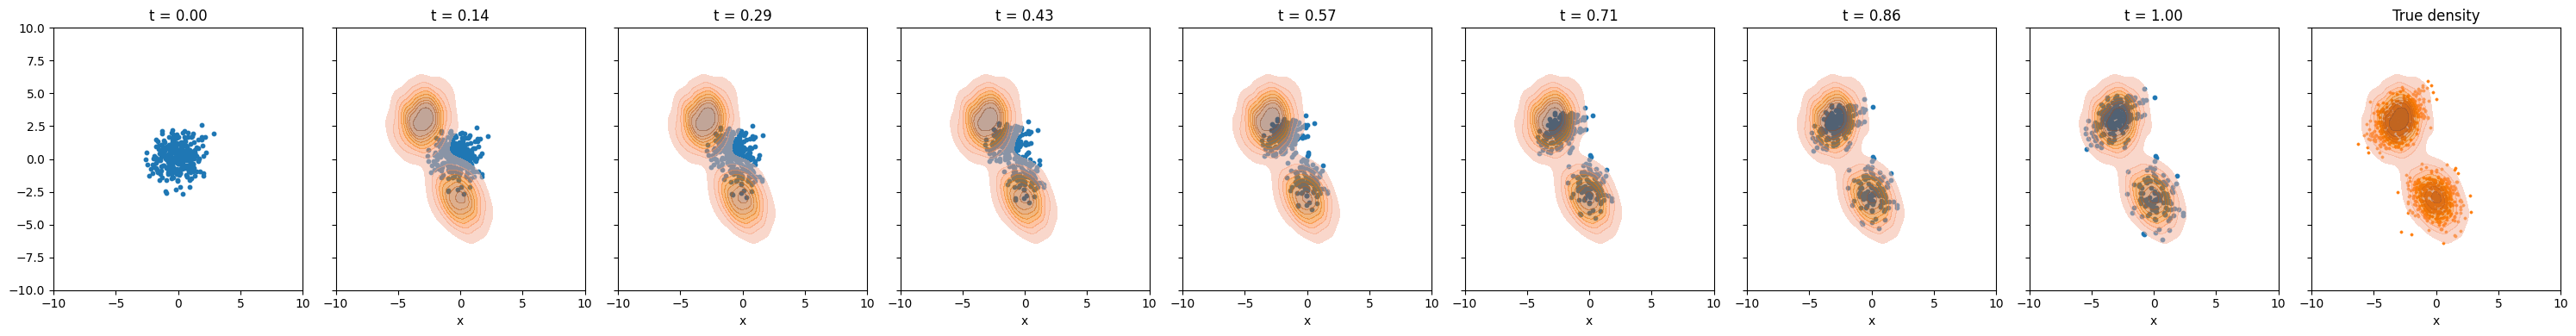

In [387]:
torch.manual_seed(SEED)
KDE_PLOT = True
KDE_GT = True

x = torch.randn(300, dim)
n_steps = 7
fig, axes = plt.subplots(1, n_steps + 2, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1)

axes[0].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-10.0, 10.0)
axes[0].set_ylim(-10.0, 10.0)

for i in range(n_steps):
    x = flow.step(x_t=x, t_start=time_steps[i], t_end=time_steps[i + 1])
    axes[i + 1].scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
    axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')
    if KDE_GT:
         # KDE contour lines (few levels)
        sns.kdeplot(
            data=df, x="x", y="y",
            levels=10,          # few contour lines
            thresh=0.05,
            color="tab:orange",
            fill=True, alpha=0.5,
            bw_adjust=1,     # tune smoothness
            ax=axes[i + 1]
        )

# True density
LIMIT = 1000

df = pd.DataFrame({"x": x0_all.detach()[:LIMIT, 0], "y": x0_all.detach()[:LIMIT, 1]})

# Scatter
sns.scatterplot(
    data=df, x="x", y="y",
    s=6, alpha=1, edgecolor=None,
    color="tab:orange", ax=axes[-1]
)

if KDE_PLOT:
    # KDE contour lines (few levels)
    sns.kdeplot(
        data=df, x="x", y="y",
        levels=10,          # few contour lines
        thresh=0.05,
        color="tab:orange",
        fill=True, alpha=0.5,
        bw_adjust=1,     # tune smoothness
        ax=axes[-1]
    )
axes[-1].set_title(f'True density')


plt.tight_layout()
plt.show()